**Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import scipy
from scipy import stats
import seaborn as sns
from functools import reduce
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

/opt/miniconda3/envs/uniprot_notebook/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


**Import processed file(s)**

Example processing with only one processed and filtered file:

In [2]:
df = pd.read_csv("./turbo_id_output/turbo_id_results_5_files/01_processed_files/processed_census-out_07302022_EV1-100A_10pl_M.csv")

In [3]:
#Rename columns according to conditions
df.columns = ["uniprot", 
              "description", 
              "pep_num", 
              "iWAT_HF_cre-_1", 
              "iWAT_HF_cre-_2", 
              "iWAT_chow_cre-_1", 
              "iWAT_chow_cre-_2", 
              "iWAT_HF_cre+_1", 
              "iWAT_HF_cre+_2", 
              "iWAT_HF_cre+_3", 
              "iWAT_chow_cre+_1", 
              "iWAT_chow_cre+_2", 
              "iWAT_chow_cre+_3",
             ]

In [4]:
#Prepare table for processing
df = df.set_index(["uniprot", 'description', 'pep_num'])

**The file contains a table of averaged raw signal intensities**

In [5]:
df.head()

,,,iWAT_HF_cre-_1,iWAT_HF_cre-_2,iWAT_chow_cre-_1,iWAT_chow_cre-_2,iWAT_HF_cre+_1,iWAT_HF_cre+_2,iWAT_HF_cre+_3,iWAT_chow_cre+_1,iWAT_chow_cre+_2,iWAT_chow_cre+_3
uniprot,description,pep_num,,,,,,,,,,
Q9Z0F7,Sncg Gamma-synuclein,10,3483.0,2865.5,2310.5,1617.0,23808.5,12014.5,28521.0,6982.5,13105.5,3358.5
P20152,Vim Vimentin,36,5710.0,6388.0,4460.5,3810.0,9778.0,11874.0,18307.0,7744.0,13584.0,7085.0
A8DUK4,Hbbt1 Protein Hbb-bs,8,2776.0,1925.0,6479.0,6293.5,7394.5,4706.5,8890.0,11554.5,11759.0,6372.5
E9QPD7,Pcx Pyruvate carboxylase,66,10465.0,8326.0,9912.0,4796.0,11582.0,9834.0,10000.0,6014.0,8387.0,6223.0
Q3ULD5,"Mccc2 Methylcrotonoyl-CoA carboxylase beta chain, mitochondrial",29,8484.5,10385.0,14965.5,8374.0,5171.5,5651.5,4870.5,9031.0,11291.5,6537.0


In [6]:
df.shape

(3079, 10)

**Calculate ratios**

- we have 2 different conditions in this file and we need to treat them seperately (HF and chow)
- each od these conditions contains treatments(cre+) and controls(cre-)
- we divide each treatment with each control 

In [207]:
def get_ratio_df(df, condition_name):

    filtered_df = df.filter(regex=condition_name)

    cond_columns = filtered_df.filter(like='cre+').columns.tolist()
    ctrl_columns = filtered_df.filter(like='cre-').columns.tolist()

    for condition in cond_columns:
        for control in ctrl_columns:
            filtered_df[condition+"/"+control+"_ratio"] = filtered_df[condition] / filtered_df[control]
        
    df_ratio = filtered_df.filter(regex='_ratio')
    return(df_ratio)
    

In [208]:
hf_df = get_ratio_df(df, "HF")
hf_df.head()

,,,iWAT_HF_cre+_1/iWAT_HF_cre-_1_ratio,iWAT_HF_cre+_1/iWAT_HF_cre-_2_ratio,iWAT_HF_cre+_2/iWAT_HF_cre-_1_ratio,iWAT_HF_cre+_2/iWAT_HF_cre-_2_ratio,iWAT_HF_cre+_3/iWAT_HF_cre-_1_ratio,iWAT_HF_cre+_3/iWAT_HF_cre-_2_ratio
uniprot,description,pep_num,,,,,,
Q9Z0F7,Sncg Gamma-synuclein,10,6.835630,8.308672,3.449469,4.192811,8.188630,9.953237
P20152,Vim Vimentin,36,1.712434,1.530683,2.079510,1.858798,3.206130,2.865842
A8DUK4,Hbbt1 Protein Hbb-bs,8,2.663725,3.841299,1.695425,2.444935,3.202450,4.618182
E9QPD7,Pcx Pyruvate carboxylase,66,1.106737,1.391064,0.939704,1.181119,0.955566,1.201057
Q3ULD5,"Mccc2 Methylcrotonoyl-CoA carboxylase beta chain, mitochondrial",29,0.609523,0.497978,0.666097,0.544198,0.574047,0.468994


In [209]:
chow_df = get_ratio_df(df, "chow")
chow_df.head()

,,,iWAT_chow_cre+_1/iWAT_chow_cre-_1_ratio,iWAT_chow_cre+_1/iWAT_chow_cre-_2_ratio,iWAT_chow_cre+_2/iWAT_chow_cre-_1_ratio,iWAT_chow_cre+_2/iWAT_chow_cre-_2_ratio,iWAT_chow_cre+_3/iWAT_chow_cre-_1_ratio,iWAT_chow_cre+_3/iWAT_chow_cre-_2_ratio
uniprot,description,pep_num,,,,,,
Q9Z0F7,Sncg Gamma-synuclein,10,3.022073,4.318182,5.672149,8.104824,1.453581,2.076994
P20152,Vim Vimentin,36,1.736128,2.032546,3.045398,3.565354,1.588387,1.859580
A8DUK4,Hbbt1 Protein Hbb-bs,8,1.783377,1.835942,1.814941,1.868436,0.983562,1.012553
E9QPD7,Pcx Pyruvate carboxylase,66,0.606739,1.253962,0.846146,1.748749,0.627825,1.297540
Q3ULD5,"Mccc2 Methylcrotonoyl-CoA carboxylase beta chain, mitochondrial",29,0.603455,1.078457,0.754502,1.348400,0.436805,0.780631


In [210]:
condition_tables = [hf_df, chow_df]

**Annotate each condition table with TP and FP lists**

- if uniprot id is in TP list the annotation column will be filled with "TP" 
- if uniprot id is in FP list the annotation column will be filled with "FP" 
- if uniprot id is in any of them annotation column will be filled with "None"

In [211]:
#get lists
FP_df = pd.read_csv("./uniprot_noteboook/combine_uniprot_IDs_per_species/mouse/00_combined/mouse_FP_list_cyt_nuc_TFs.csv")
FP_list = FP_df["Entry"].tolist()
print("Number of Uniport IDs in FP list:", len(FP_list))
TP_df = pd.read_csv("./uniprot_noteboook/combine_uniprot_IDs_per_species/mouse/00_combined/mouse_TP_list_secreted.csv")
TP_list = TP_df["Entry"].tolist()
print("Number of Uniport IDs in TP list:", len(TP_list))

Number of Uniport IDs in FP list: 8342
Number of Uniport IDs in TP list: 6952


In [212]:
def annotate_uniprot(uniprot_id):
    if uniprot_id in TP_list:
        return "TP"
    elif uniprot_id in FP_list:
        return "FP"

In [213]:
annotated_tables = []
for table in condition_tables:
    table = table.reset_index()
    uniprot_ids = table["uniprot"]
    table["annotation"] = table["uniprot"].apply(annotate_uniprot)
    table = table.set_index(["uniprot", 'description', 'pep_num', 'annotation'])
    annotated_tables.append(table)

print("Example for one condition:")
annotated_tables[0].head()

Example for one condition:


,,,,iWAT_HF_cre+_1/iWAT_HF_cre-_1_ratio,iWAT_HF_cre+_1/iWAT_HF_cre-_2_ratio,iWAT_HF_cre+_2/iWAT_HF_cre-_1_ratio,iWAT_HF_cre+_2/iWAT_HF_cre-_2_ratio,iWAT_HF_cre+_3/iWAT_HF_cre-_1_ratio,iWAT_HF_cre+_3/iWAT_HF_cre-_2_ratio
uniprot,description,pep_num,annotation,,,,,,
Q9Z0F7,Sncg Gamma-synuclein,10,FP,6.835630,8.308672,3.449469,4.192811,8.188630,9.953237
P20152,Vim Vimentin,36,FP,1.712434,1.530683,2.079510,1.858798,3.206130,2.865842
A8DUK4,Hbbt1 Protein Hbb-bs,8,NaN,2.663725,3.841299,1.695425,2.444935,3.202450,4.618182
E9QPD7,Pcx Pyruvate carboxylase,66,NaN,1.106737,1.391064,0.939704,1.181119,0.955566,1.201057
Q3ULD5,"Mccc2 Methylcrotonoyl-CoA carboxylase beta chain, mitochondrial",29,NaN,0.609523,0.497978,0.666097,0.544198,0.574047,0.468994


For the next steps we followed methods section "Data analysis" of https://www.nature.com/articles/s41596-020-0399-0

- Analyze each replicate seperately

- Normalize corresponding TMT ratios against the distribution of FP proteins that should not be biotinylated by TurboID (FP list). To do this, divide all TMT ratios by the median of the ratios for FP proteins.

- Calculate the log2 value of each ratio; log2 values will be used for the rest of the analysis. This normalization centers the distribution of the log2 ratios of nonspecifically binding proteins around 0.

- Check the correlation between replicates by plotting the corresponding log2 ratios. 

- Rank the proteins by the appropriate TMT ratio values in descending order and cross this list with the TP and FP lists to determine which proteins are TPs and FPs, respectively.

- At each potential cutoff, calculate the TPR and FP rate (FPR), where the TPR/FPR is defined as the number of detected TP/FP proteins detected above the cutoff divided by the total number of detected TP/FP proteins in that replicate. A plot of the TPR versus the FPR should show that the curve bows out as compared with the diagonal, which shows that the proteomic experiment successfully enriched TP proteins over FP proteins (Fig. 4c).

- Determine the cutoff by using the log2 ratio that corresponds to the maximum TPR-FPR value. In cases in which the list of TP proteins is small (e.g., ER–mitochondria contacts; Fig. 5a–d), the cutoff can be alternatively determined with a FDR cutoff (Fig. 5d), where FDR is defined as the fraction of FP proteins detected above each cutoff.

- Retain all proteins with log2 ratios higher than that of the determined cutoff.

Analyzing:  iWAT_HF_cre+_1/iWAT_HF_cre-_1_ratio
     uniprot annotation  iWAT_HF_cre+_1/iWAT_HF_cre-_1_ratio  original_ratio
1390  Q9R1P1         FP                                  NaN             NaN
2354  B1AVZ0         FP                                  NaN             NaN
Number of proteins without nans for ratio: 3077
Number of annotated TP:  286
Number of annotated FP:  856


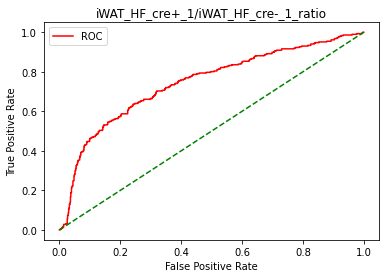

Cutoff value: 0.5483736583160415


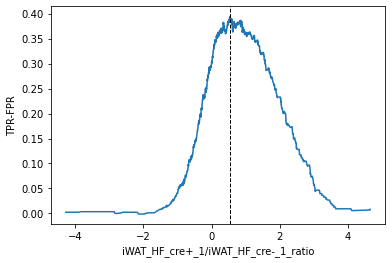

Analyzing:  iWAT_HF_cre+_1/iWAT_HF_cre-_2_ratio
    uniprot annotation  iWAT_HF_cre+_1/iWAT_HF_cre-_2_ratio  original_ratio
857  Q9D2Q8        NaN                                  NaN             NaN
Number of proteins without nans for ratio: 3078
Number of annotated TP:  286
Number of annotated FP:  858


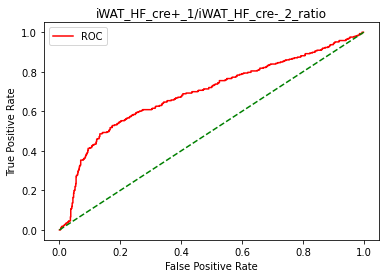

Cutoff value: 0.8727707396354116


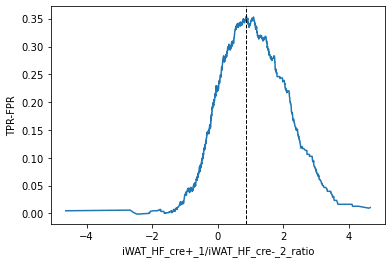

Analyzing:  iWAT_HF_cre+_2/iWAT_HF_cre-_1_ratio
     uniprot annotation  iWAT_HF_cre+_2/iWAT_HF_cre-_1_ratio  original_ratio
1390  Q9R1P1         FP                                  NaN             NaN
2610  E9PYR1        NaN                                  NaN             NaN
2617  Q99KE1        NaN                                  NaN             NaN
2814  Q8CGW4         FP                                  NaN             NaN
Number of proteins without nans for ratio: 3075
Number of annotated TP:  286
Number of annotated FP:  856


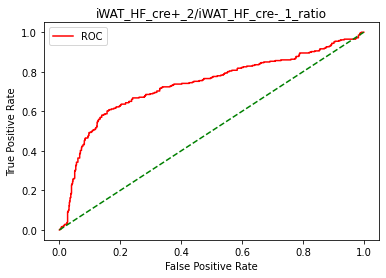

Cutoff value: 0.7174982052461591


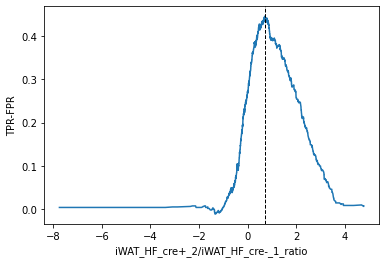

Analyzing:  iWAT_HF_cre+_2/iWAT_HF_cre-_2_ratio
     uniprot annotation  iWAT_HF_cre+_2/iWAT_HF_cre-_2_ratio  original_ratio
267   Q8VE95        NaN                                  NaN             NaN
805   P62307         FP                                  NaN             NaN
857   Q9D2Q8        NaN                                  NaN             NaN
1075  Q9D8S9        NaN                                  NaN             NaN
1843  O09131        NaN                                  NaN             NaN
1928  Q9Z2W0        NaN                                  NaN             NaN
2002  Q9CW42        NaN                                  NaN             NaN
2790  Q8BP56        NaN                                  NaN             NaN
2815  P49290        NaN                                  NaN             NaN
2945  Q3V1D3        NaN                                  NaN             NaN
3063  E9Q309         FP                                  NaN             NaN
Number of proteins without n

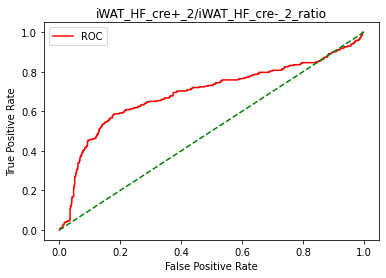

Cutoff value: 0.7177824358436015


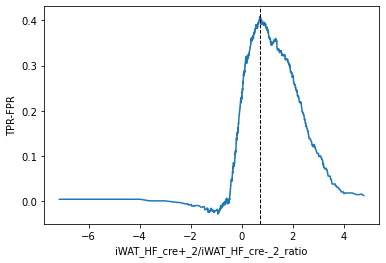

Analyzing:  iWAT_HF_cre+_3/iWAT_HF_cre-_1_ratio
Empty DataFrame
Columns: [uniprot, annotation, iWAT_HF_cre+_3/iWAT_HF_cre-_1_ratio, original_ratio]
Index: []
Number of proteins without nans for ratio: 3079
Number of annotated TP:  286
Number of annotated FP:  858


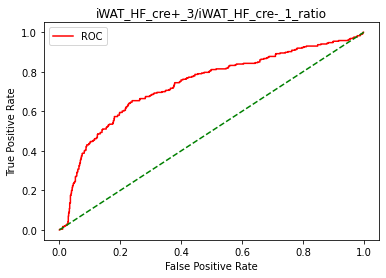

Cutoff value: 0.607105846432624


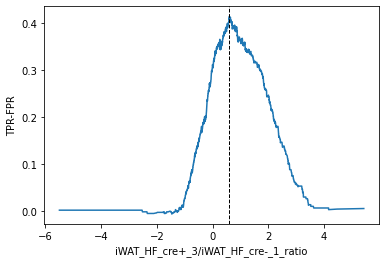

Analyzing:  iWAT_HF_cre+_3/iWAT_HF_cre-_2_ratio
     uniprot annotation  iWAT_HF_cre+_3/iWAT_HF_cre-_2_ratio  original_ratio
267   Q8VE95        NaN                                  NaN             NaN
857   Q9D2Q8        NaN                                  NaN             NaN
1746  Q8BFQ4         FP                                  NaN             NaN
Number of proteins without nans for ratio: 3076
Number of annotated TP:  286
Number of annotated FP:  857


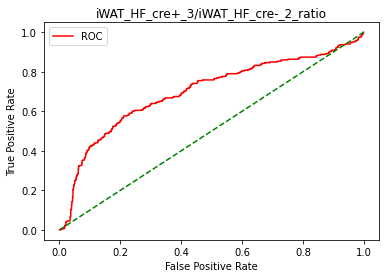

Cutoff value: 0.8088985159632831


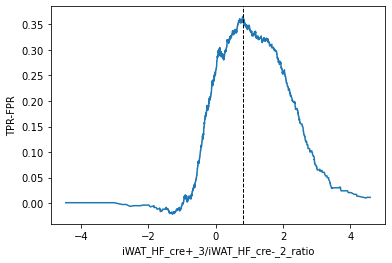

Analyzing:  iWAT_chow_cre+_1/iWAT_chow_cre-_1_ratio
     uniprot annotation  iWAT_chow_cre+_1/iWAT_chow_cre-_1_ratio  \
602   Q9CPQ8        NaN                                      NaN   
748   P05132         FP                                      NaN   
857   Q9D2Q8        NaN                                      NaN   
1130  Q9DB73        NaN                                      NaN   
1357  Q3TBT3        NaN                                      NaN   
1746  Q8BFQ4         FP                                      NaN   
1802  Q9D8Y1        NaN                                      NaN   
1843  O09131        NaN                                      NaN   
2002  Q9CW42        NaN                                      NaN   
2118  Q8R2V5        NaN                                      NaN   
2135  D3YX87        NaN                                      NaN   
2261  Q69ZP3         FP                                      NaN   
2301  Q99M74        NaN                                      NaN

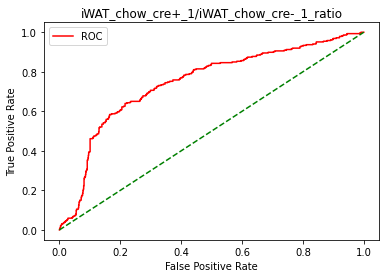

Cutoff value: 0.8109508886704133


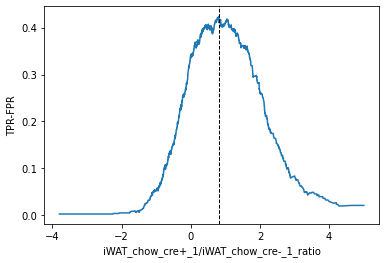

Analyzing:  iWAT_chow_cre+_1/iWAT_chow_cre-_2_ratio
     uniprot annotation  iWAT_chow_cre+_1/iWAT_chow_cre-_2_ratio  \
128   P84244         FP                                      NaN   
602   Q9CPQ8        NaN                                      NaN   
603   P03903        NaN                                      NaN   
748   P05132         FP                                      NaN   
857   Q9D2Q8        NaN                                      NaN   
1130  Q9DB73        NaN                                      NaN   
1210  P28658        NaN                                      NaN   
1357  Q3TBT3        NaN                                      NaN   
1449  Q9D1A0        NaN                                      NaN   
1746  Q8BFQ4         FP                                      NaN   
1802  Q9D8Y1        NaN                                      NaN   
1843  O09131        NaN                                      NaN   
1962  Q8C142        NaN                                      NaN

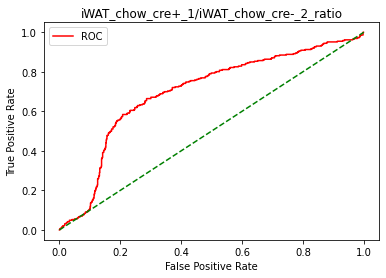

Cutoff value: 0.5414422281605761


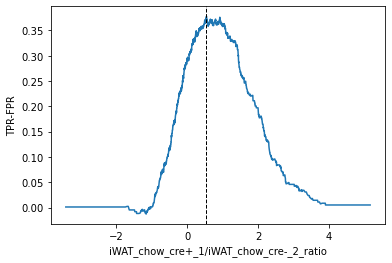

Analyzing:  iWAT_chow_cre+_2/iWAT_chow_cre-_1_ratio
     uniprot annotation  iWAT_chow_cre+_2/iWAT_chow_cre-_1_ratio  \
602   Q9CPQ8        NaN                                      NaN   
748   P05132         FP                                      NaN   
857   Q9D2Q8        NaN                                      NaN   
1390  Q9R1P1         FP                                      NaN   
1843  O09131        NaN                                      NaN   
2002  Q9CW42        NaN                                      NaN   
2118  Q8R2V5        NaN                                      NaN   
2261  Q69ZP3         FP                                      NaN   
2610  E9PYR1        NaN                                      NaN   
2821  Q9Z2D3        NaN                                      NaN   

      original_ratio  
602              NaN  
748              NaN  
857              NaN  
1390             NaN  
1843             NaN  
2002             NaN  
2118             NaN  
2261           

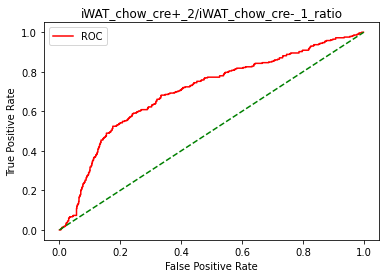

Cutoff value: 1.0840458271386073


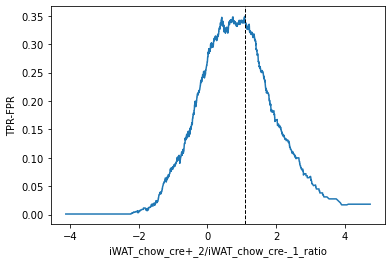

Analyzing:  iWAT_chow_cre+_2/iWAT_chow_cre-_2_ratio
     uniprot annotation  iWAT_chow_cre+_2/iWAT_chow_cre-_2_ratio  \
128   P84244         FP                                      NaN   
602   Q9CPQ8        NaN                                      NaN   
748   P05132         FP                                      NaN   
857   Q9D2Q8        NaN                                      NaN   
1390  Q9R1P1         FP                                      NaN   
1564  Q9DCF9        NaN                                      NaN   
1843  O09131        NaN                                      NaN   
2002  Q9CW42        NaN                                      NaN   
2118  Q8R2V5        NaN                                      NaN   
2261  Q69ZP3         FP                                      NaN   
2610  E9PYR1        NaN                                      NaN   
2821  Q9Z2D3        NaN                                      NaN   

      original_ratio  
128              NaN  
602              

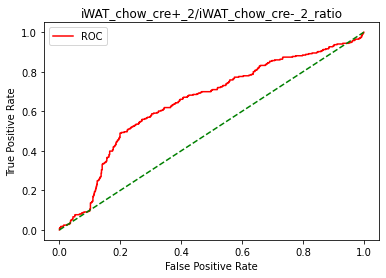

Cutoff value: 1.0386229593822083


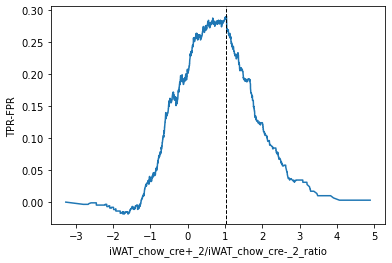

Analyzing:  iWAT_chow_cre+_3/iWAT_chow_cre-_1_ratio
     uniprot annotation  iWAT_chow_cre+_3/iWAT_chow_cre-_1_ratio  \
562   P33622         TP                                      NaN   
727   P50543         FP                                      NaN   
748   P05132         FP                                      NaN   
805   P62307         FP                                      NaN   
857   Q9D2Q8        NaN                                      NaN   
1390  Q9R1P1         FP                                      NaN   
1428  P23953        NaN                                      NaN   
1538  P46664        NaN                                      NaN   
1593  Q9D2W5        NaN                                      NaN   
1656  Q62181         TP                                      NaN   
1843  O09131        NaN                                      NaN   
1859  P97823         TP                                      NaN   
2002  Q9CW42        NaN                                      NaN

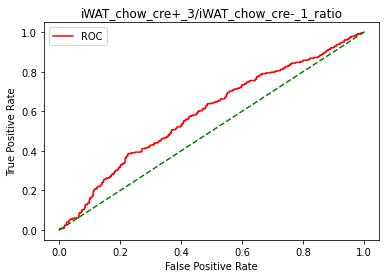

Cutoff value: 0.7820760240380769


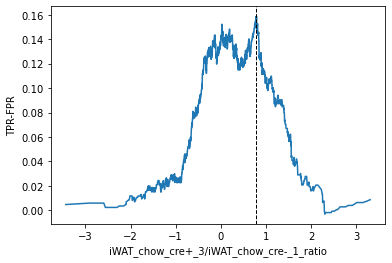

Analyzing:  iWAT_chow_cre+_3/iWAT_chow_cre-_2_ratio
     uniprot annotation  iWAT_chow_cre+_3/iWAT_chow_cre-_2_ratio  \
128   P84244         FP                                      NaN   
172   Q8BSL7        NaN                                      NaN   
603   P03903        NaN                                      NaN   
748   P05132         FP                                      NaN   
805   P62307         FP                                      NaN   
857   Q9D2Q8        NaN                                      NaN   
1034  Q61206        NaN                                      NaN   
1257  Q9QXB9         FP                                      NaN   
1361  P49722         FP                                      NaN   
1390  Q9R1P1         FP                                      NaN   
1538  P46664        NaN                                      NaN   
1593  Q9D2W5        NaN                                      NaN   
1656  Q62181         TP                                      NaN

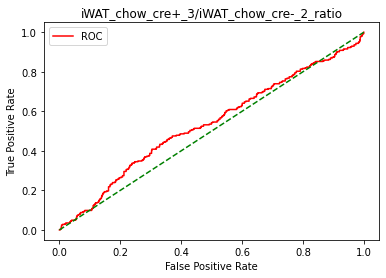

Cutoff value: 0.47714202674590145


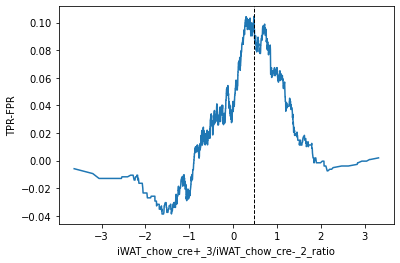

In [214]:
all_cond_cutoff_tables = []
condition_table = []

for table in annotated_tables:
    condition_cutoff_table = []
    
    columns_list = table.columns.tolist()
    
    table = table.reset_index()
    
    for column in columns_list:
        
        #get replicate
        df_rep = table[["uniprot", "annotation", column]]
        
        print("Analyzing: ", column)
        #print("Number of proteins with nans:", df_rep.shape[0])
        
        #normalize ratios
        df_rep["original_ratio"] = df_rep[column]
        median_FP_ratio = df_rep.loc[df_rep['annotation'] == 'FP', column].median()
        df_rep[column] = df_rep[column].div(median_FP_ratio)
        df_rep[column] = np.log2(df_rep[column]) 

        #remove infs and nas
        #df_rep[column].replace([np.inf, -np.inf], np.nan, inplace=True)
        #df_rep[column].replace([np.inf], np.nan, inplace=True)
        
        print(df_rep[df_rep[column].isna()])
        df_rep = df_rep[df_rep[column].notna()]
        
        print("Number of proteins without nans for ratio:", df_rep.shape[0])
        #get total number of annotated TP and FP
        total_TP = len(df_rep[df_rep["annotation"] == "TP"])
        total_FP = len(df_rep[df_rep["annotation"] == "FP"])
        print("Number of annotated TP: ", total_TP)
        print("Number of annotated FP: ", total_FP)
        
        #rank ratio in descending order
        df_rep = df_rep.sort_values(column, ascending=False)
        
        #clean up index
        df_rep = df_rep.reset_index(drop=True)
        #get index as list
        index_list = df_rep.index.values.tolist()
        
        #for each row calculate number of TP and FP in all the rows before
        for row_number in index_list:
            if row_number == 0:
                df_rep.loc[df_rep.index[row_number], 'FP'] = 0
                df_rep.loc[df_rep.index[row_number], 'TP'] = 0
            
            else:
                results_dict = {}
                subset_df = df_rep.loc[0:row_number-1]
                for idx, name in enumerate(subset_df.annotation.value_counts().index.tolist()):
                    results_dict[name] = subset_df.annotation.value_counts()[idx]

                if 'FP' in results_dict:
                    df_rep.loc[df_rep.index[row_number], 'FP'] = results_dict["FP"]
                else:
                    df_rep.loc[df_rep.index[row_number], 'FP'] = 0
                if 'TP' in results_dict:
                    df_rep.loc[df_rep.index[row_number], 'TP'] = results_dict["TP"]
                else:
                    df_rep.loc[df_rep.index[row_number], 'TP'] = 0

        #calculate TPR and FPR
        df_rep["TPR"] = df_rep["TP"] / total_TP
        df_rep["FPR"] = df_rep["FP"] / total_FP
        
        #plot TPR and FPR 
        plt.plot(df_rep["FPR"], df_rep["TPR"], color='red', label='ROC')
        plt.plot([0, 1], [0, 1], color='green', linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(column)
        plt.legend()
        plt.show()
        
        #calculate TPR-FPR, get cutoff value = maximum TPR-FPR value
        df_rep["TPR-FPR"] = df_rep["TPR"] - df_rep["FPR"]
        cutoff_value = df_rep.loc[df_rep["TPR-FPR"].idxmax()][column]
        print("Cutoff value:", cutoff_value)
    
        #plot log2 ratio and TPR-FPR
        ax = sns.lineplot(df_rep[column], df_rep["TPR-FPR"])
    
        #xlabel_string = "Log2(" + column + ")"
        # Setting the X and Y Label
        #ax.set_xlabel(xlabel_string)
        ax.set_xlabel(column)
        ax.set_ylabel('TPR-FPR')
        ax.axvline(cutoff_value, linewidth=1, color="black", linestyle = "--")
        plt.show()
    
        #Retain all proteins with log2 ratios higher than that of the determined cutoff
        df_rep_cutoff = df_rep[df_rep[column] > cutoff_value]
        #df_rep_cutoff = df_rep[df_rep["FPR"] < 0.1] FDR 10 %
        
        condition_cutoff_table.append(df_rep_cutoff)
        condition_table.append(df_rep)
        #print(df_rep[column].min())
        #column = column.replace("/", "-")
        #filename = column +".csv"
        #df_rep.to_csv(filename)
        #rep_protein_dfs_which_pass_cutoff.append(df_rep)

    all_cond_cutoff_tables.append(condition_cutoff_table)

**Example of a replicate table**

In [215]:
df_rep.head()

,uniprot,annotation,iWAT_chow_cre+_3/iWAT_chow_cre-_2_ratio,original_ratio,FP,TP,TPR,FPR,TPR-FPR
0,P70698,NaN,inf,inf,0.0,0.0,0.0,0.000000,0.000000
1,P30999,FP,inf,inf,0.0,0.0,0.0,0.000000,0.000000
2,Q68FE6,NaN,inf,inf,1.0,0.0,0.0,0.001178,-0.001178
3,O08810,FP,inf,inf,1.0,0.0,0.0,0.001178,-0.001178
4,Q8BZ03,NaN,inf,inf,2.0,0.0,0.0,0.002356,-0.002356


In [216]:
df_rep.tail()

,uniprot,annotation,iWAT_chow_cre+_3/iWAT_chow_cre-_2_ratio,original_ratio,FP,TP,TPR,FPR,TPR-FPR
3032,Q08AT1,NaN,-inf,0.0,849.0,282.0,0.992958,1.0,-0.007042
3033,P55065,TP,-inf,0.0,849.0,282.0,0.992958,1.0,-0.007042
3034,P23953,NaN,-inf,0.0,849.0,283.0,0.996479,1.0,-0.003521
3035,P33622,TP,-inf,0.0,849.0,283.0,0.996479,1.0,-0.003521
3036,Q6NXH9,NaN,-inf,0.0,849.0,284.0,1.000000,1.0,0.000000


In [217]:
df_rep.describe()

,iWAT_chow_cre+_3/iWAT_chow_cre-_2_ratio,original_ratio,FP,TP,TPR,FPR,TPR-FPR
count,3037.000000,3037.000000,3037.000000,3037.000000,3037.000000,3037.000000,3037.000000
mean,NaN,inf,432.746460,154.074416,0.542516,0.509713,0.032802
std,NaN,NaN,253.768723,79.568383,0.280170,0.298903,0.038209
min,-inf,0.000000,0.000000,0.000000,0.000000,0.000000,-0.038670
25%,-0.662088,1.671212,211.000000,98.000000,0.345070,0.248528,0.008121
50%,-0.038492,2.574854,441.000000,157.000000,0.552817,0.519435,0.029451
75%,0.686865,4.257028,655.000000,223.000000,0.785211,0.771496,0.062758
max,inf,inf,849.000000,284.000000,1.000000,1.000000,0.104564


In [218]:
#df_rep["original_ratio"].plot.box()

**Example subset of proteins above cutoff**

In [221]:
print("Cutoff:", cutoff_value)

Cutoff: 0.47714202674590145


In [222]:
df_rep_cutoff.describe()

,iWAT_chow_cre+_3/iWAT_chow_cre-_2_ratio,original_ratio,FP,TP,TPR,FPR,TPR-FPR
count,931.000000,931.000000,931.000000,931.000000,931.000000,931.000000,931.000000
mean,inf,inf,126.994629,54.787325,0.192913,0.149581,0.043332
std,NaN,NaN,77.051002,35.029326,0.123343,0.090755,0.034581
min,0.477500,3.681981,0.000000,0.000000,0.000000,0.000000,-0.007416
25%,0.772248,4.516580,57.000000,23.000000,0.080986,0.067138,0.011443
50%,1.290133,6.467085,126.000000,55.000000,0.193662,0.148410,0.039400
75%,NaN,NaN,195.000000,90.000000,0.316901,0.229682,0.080679
max,inf,inf,258.000000,115.000000,0.404930,0.303887,0.101043


In [223]:
#df_rep_cutoff["original_ratio"].plot.box()

**For each replicate get number of proteins that pass cutoff**

In [224]:
print("Proteins that pass cutoff:")
print("")

for condition_tables in all_cond_cutoff_tables:
    for table in condition_tables:
        col_name = table.columns.tolist()[-7]
        print(col_name)
        print("Number of proteins", table.shape[0])
        #get total number of annotated TP and FP
        total_TP = len(table[table["annotation"] == "TP"])
        total_FP = len(table[table["annotation"] == "FP"])
        print("Number of annotated TP: ", total_TP)
        print("Number of annotated FP: ", total_FP)
        print("")
        table.rename(columns={"FP": "FP_"+col_name, 
                              "TP": "TP_"+col_name, 
                              "TPR": "TPR_"+col_name, 
                              "FPR": "FPR_"+col_name, 
                              "TPR-FPR": "TPR-FPR_"+col_name, 
                              "TPR-FPR": "TPR-FPR_"+col_name,
                              "original_ratio": "original_ratio_"+col_name,}, inplace=True)
        
        

Proteins that pass cutoff:

iWAT_HF_cre+_1/iWAT_HF_cre-_1_ratio
Number of proteins 1080
Number of annotated TP:  182
Number of annotated FP:  207

iWAT_HF_cre+_1/iWAT_HF_cre-_2_ratio
Number of proteins 898
Number of annotated TP:  151
Number of annotated FP:  149

iWAT_HF_cre+_2/iWAT_HF_cre-_1_ratio
Number of proteins 777
Number of annotated TP:  172
Number of annotated FP:  134

iWAT_HF_cre+_2/iWAT_HF_cre-_2_ratio
Number of proteins 860
Number of annotated TP:  168
Number of annotated FP:  153

iWAT_HF_cre+_3/iWAT_HF_cre-_1_ratio
Number of proteins 972
Number of annotated TP:  187
Number of annotated FP:  205

iWAT_HF_cre+_3/iWAT_HF_cre-_2_ratio
Number of proteins 905
Number of annotated TP:  165
Number of annotated FP:  181

iWAT_chow_cre+_1/iWAT_chow_cre-_1_ratio
Number of proteins 908
Number of annotated TP:  183
Number of annotated FP:  184

iWAT_chow_cre+_1/iWAT_chow_cre-_2_ratio
Number of proteins 1068
Number of annotated TP:  190
Number of annotated FP:  244

iWAT_chow_cre+_2/i

**Merge replicates of the same condition into one table and get proteins that are contained in all replicates of this condition (inner merge)**

In [225]:
for condition_tables in all_cond_cutoff_tables:
    df = reduce(lambda df1,df2: pd.merge(df1,df2,on=['uniprot', 'annotation']), condition_tables)
    col_list = condition_tables[0].columns.tolist()
    if "iWAT_HF_cre+_1/iWAT_HF_cre-_1_ratio" in col_list:
        df.to_csv("hf.csv")
        print("HF condition")
    elif "iWAT_chow_cre+_1/iWAT_chow_cre-_1_ratio" in col_list:
        df.to_csv("chow.csv")
        print("Chow condition")
    
    print("Number of proteins for all replicates (inner merge): ", df.shape[0])
    total_TP = len(df[df["annotation"] == "TP"])
    total_FP = len(df[df["annotation"] == "FP"])
    print("Number of annotated TP: ", total_TP)
    print("Number of annotated FP: ", total_FP)
    

HF condition
Number of proteins for all replicates (inner merge):  544
Number of annotated TP:  133
Number of annotated FP:  73
Chow condition
Number of proteins for all replicates (inner merge):  364
Number of annotated TP:  79
Number of annotated FP:  76


**Merge replicates of the same condition into one table and get everything in one table (outer merge)**

In [226]:
for condition_tables in all_cond_cutoff_tables:
    df = reduce(lambda df1,df2: pd.merge(df1,df2,on=['uniprot', 'annotation'], how="outer"), condition_tables)
    col_list = condition_tables[0].columns.tolist()
    if "iWAT_HF_cre+_1/iWAT_HF_cre-_1_ratio" in col_list:
        hf_df = df
        df.to_csv("hf.csv")
        print("HF condition")
    elif "iWAT_chow_cre+_1/iWAT_chow_cre-_1_ratio" in col_list:
        chow_df = df
        df.to_csv("chow.csv")
        print("Chow condition")
    
    print("Number of proteins for all replicates (inner merge): ", df.shape[0])
    total_TP = len(df[df["annotation"] == "TP"])
    total_FP = len(df[df["annotation"] == "FP"])
    print("Number of annotated TP: ", total_TP)
    print("Number of annotated FP: ", total_FP)
    

HF condition
Number of proteins for all replicates (inner merge):  1402
Number of annotated TP:  208
Number of annotated FP:  308
Chow condition
Number of proteins for all replicates (inner merge):  1444
Number of annotated TP:  207
Number of annotated FP:  366


**Merge HF and chow together and add raw singal intensity information**

In [378]:
df_list = [hf_df, chow_df]

In [379]:
df_all = reduce(lambda df1,df2: pd.merge(df1,df2,on=['uniprot', 'annotation'], how="outer"), df_list)

In [380]:
df_all.shape

(1825, 86)

In [381]:
tp_cols = df_all.filter(like='TP_').columns.tolist()
fp_cols = df_all.filter(like='FP_').columns.tolist()

In [382]:
df_all.drop(tp_cols, axis=1, inplace=True)
df_all.drop(fp_cols, axis=1, inplace=True)

In [383]:
df_all.shape

(1825, 62)

In [384]:
df_all

,uniprot,annotation,iWAT_HF_cre+_1/iWAT_HF_cre-_1_ratio,original_ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_1_ratio,TPR_iWAT_HF_cre+_1/iWAT_HF_cre-_1_ratio,FPR_iWAT_HF_cre+_1/iWAT_HF_cre-_1_ratio,TPR-FPR_iWAT_HF_cre+_1/iWAT_HF_cre-_1_ratio,iWAT_HF_cre+_1/iWAT_HF_cre-_2_ratio,original_ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_2_ratio,TPR_iWAT_HF_cre+_1/iWAT_HF_cre-_2_ratio,...,iWAT_chow_cre+_3/iWAT_chow_cre-_1_ratio,original_ratio_iWAT_chow_cre+_3/iWAT_chow_cre-_1_ratio,TPR_iWAT_chow_cre+_3/iWAT_chow_cre-_1_ratio,FPR_iWAT_chow_cre+_3/iWAT_chow_cre-_1_ratio,TPR-FPR_iWAT_chow_cre+_3/iWAT_chow_cre-_1_ratio,iWAT_chow_cre+_3/iWAT_chow_cre-_2_ratio,original_ratio_iWAT_chow_cre+_3/iWAT_chow_cre-_2_ratio,TPR_iWAT_chow_cre+_3/iWAT_chow_cre-_2_ratio,FPR_iWAT_chow_cre+_3/iWAT_chow_cre-_2_ratio,TPR-FPR_iWAT_chow_cre+_3/iWAT_chow_cre-_2_ratio
0,Q9JMG3,FP,inf,inf,0.000000,0.000000,0.000000,NaN,NaN,NaN,...,3.005866,14.562357,0.060284,0.053991,0.006293,2.034335,10.832669,0.105634,0.106007,-0.000373
1,Q91XL3,NaN,inf,inf,0.000000,0.001168,-0.001168,2.228865,12.335294,0.251748,...,NaN,NaN,NaN,NaN,NaN,inf,inf,0.028169,0.011779,0.016390
2,P54728,FP,inf,inf,0.000000,0.001168,-0.001168,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,P21956,TP,inf,inf,0.000000,0.002336,-0.002336,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,inf,inf,0.007042,0.005889,0.001153
4,O89001,NaN,inf,inf,0.003497,0.002336,0.001160,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,inf,inf,0.073944,0.058893,0.015051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,F8VPR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.524809,3.804722,0.380282,0.296820,0.083462
1821,Q7TT50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.505281,3.753568,0.387324,0.300353,0.086971
1822,P58854,FP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.501001,3.742450,0.387324,0.300353,0.086971
1823,P08103,FP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.500334,3.740719,0.387324,0.301531,0.085793


In [385]:
df = pd.read_csv("./turbo_id_output/turbo_id_results_5_files/01_processed_files/processed_census-out_07302022_EV1-100A_10pl_M.csv")
#Rename columns according to conditions
df.columns = ["uniprot", 
              "description", 
              "pep_num", 
              "iWAT_HF_cre-_1", 
              "iWAT_HF_cre-_2", 
              "iWAT_chow_cre-_1", 
              "iWAT_chow_cre-_2", 
              "iWAT_HF_cre+_1", 
              "iWAT_HF_cre+_2", 
              "iWAT_HF_cre+_3", 
              "iWAT_chow_cre+_1", 
              "iWAT_chow_cre+_2", 
              "iWAT_chow_cre+_3",
             ]

In [386]:
df_merged_all = df_all.merge(df, on=["uniprot"], how="left")

In [387]:
df_merged_all.columns = df_merged_all.columns.str.replace("_ratio", "")

In [388]:
df_merged_all.columns = df_merged_all.columns.str.replace("original", "ratio")

In [389]:
col_list = df_merged_all.columns.tolist()

In [390]:
new_col_list = []
for item in col_list:
    if item.startswith("i") and "/" in item:
        item = "log2_norm_ratio_" + item 
        new_col_list.append(item)
    else:
        new_col_list.append(item)

In [391]:
df_merged_all.columns = new_col_list

In [392]:
#df_merged_all.to_csv("hf_chow_EV1-100A_after_cutoff.csv")

In [393]:
df_merged_all

,uniprot,annotation,log2_norm_ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_1,ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_1,TPR_iWAT_HF_cre+_1/iWAT_HF_cre-_1,FPR_iWAT_HF_cre+_1/iWAT_HF_cre-_1,TPR-FPR_iWAT_HF_cre+_1/iWAT_HF_cre-_1,log2_norm_ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_2,ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_2,TPR_iWAT_HF_cre+_1/iWAT_HF_cre-_2,...,iWAT_HF_cre-_1,iWAT_HF_cre-_2,iWAT_chow_cre-_1,iWAT_chow_cre-_2,iWAT_HF_cre+_1,iWAT_HF_cre+_2,iWAT_HF_cre+_3,iWAT_chow_cre+_1,iWAT_chow_cre+_2,iWAT_chow_cre+_3
0,Q9JMG3,FP,inf,inf,0.000000,0.000000,0.000000,NaN,NaN,NaN,...,0.0,1936.0,1307.0,1757.0,7615.0,7671.0,8357.0,42440.0,30037.0,19033.0
1,Q91XL3,NaN,inf,inf,0.000000,0.001168,-0.001168,2.228865,12.335294,0.251748,...,0.0,1190.0,1971.0,0.0,14679.0,9248.0,16271.0,6037.0,9320.0,3555.0
2,P54728,FP,inf,inf,0.000000,0.001168,-0.001168,NaN,NaN,NaN,...,0.0,1664.0,1889.0,1467.0,5154.0,2544.0,4437.0,1471.0,2648.0,3239.0
3,P21956,TP,inf,inf,0.000000,0.002336,-0.002336,NaN,NaN,NaN,...,0.0,1680.0,1193.0,0.0,6919.0,5107.0,7000.0,5320.0,4691.0,1875.0
4,O89001,NaN,inf,inf,0.003497,0.002336,0.001160,NaN,NaN,NaN,...,0.0,1178.0,984.0,0.0,5492.0,3915.0,7895.0,6975.0,9480.0,2505.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,F8VPR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4224.5,3601.0,5828.0,2965.0,4427.0,6847.5,7422.5,7298.5,19959.0,11281.0
1821,Q7TT50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2535.5,1977.5,1900.5,1191.0,6230.0,4380.0,6361.5,3051.0,4885.5,4470.5
1822,P58854,FP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2762.0,3885.0,2870.0,1755.0,6753.0,6846.0,8363.0,5348.0,8911.0,6568.0
1823,P08103,FP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2205.0,2116.0,3136.0,1724.0,5229.0,2139.0,3747.0,4480.0,7715.0,6449.0


In [394]:
cols_ratio = df_merged_all.filter(like='ratio_').columns.tolist()

In [395]:
new_list = []
for name in cols_ratio:
    if not "log2" in name:
        new_list.append(name)

In [396]:
new_list

['ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_1',
 'ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_2',
 'ratio_iWAT_HF_cre+_2/iWAT_HF_cre-_1',
 'ratio_iWAT_HF_cre+_2/iWAT_HF_cre-_2',
 'ratio_iWAT_HF_cre+_3/iWAT_HF_cre-_1',
 'ratio_iWAT_HF_cre+_3/iWAT_HF_cre-_2',
 'ratio_iWAT_chow_cre+_1/iWAT_chow_cre-_1',
 'ratio_iWAT_chow_cre+_1/iWAT_chow_cre-_2',
 'ratio_iWAT_chow_cre+_2/iWAT_chow_cre-_1',
 'ratio_iWAT_chow_cre+_2/iWAT_chow_cre-_2',
 'ratio_iWAT_chow_cre+_3/iWAT_chow_cre-_1',
 'ratio_iWAT_chow_cre+_3/iWAT_chow_cre-_2']

In [397]:
new_list.append("uniprot")
new_list.append("annotation")

In [398]:
subdf = df_merged_all[new_list]
subdf = subdf.set_index(["uniprot", "annotation"])

In [399]:
subdf = subdf.reset_index()

In [400]:
ratio_raw_values = subdf.merge(df, on=["uniprot"], how="left")

In [401]:
ratio_raw_values.to_csv("ratio_raw_values_hf_chow_EV1-100A_after_cutoff.csv")

In [402]:
new_list = new_list[0:-2]

In [403]:
df_merged_all.drop(new_list, axis=1, inplace=True)

In [409]:
df_merged_all.shape
df_merged_all.iloc[:, 0:-11]

,uniprot,annotation,log2_norm_ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_1,TPR_iWAT_HF_cre+_1/iWAT_HF_cre-_1,FPR_iWAT_HF_cre+_1/iWAT_HF_cre-_1,TPR-FPR_iWAT_HF_cre+_1/iWAT_HF_cre-_1,log2_norm_ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_2,TPR_iWAT_HF_cre+_1/iWAT_HF_cre-_2,FPR_iWAT_HF_cre+_1/iWAT_HF_cre-_2,TPR-FPR_iWAT_HF_cre+_1/iWAT_HF_cre-_2,...,TPR-FPR_iWAT_chow_cre+_2/iWAT_chow_cre-_2,log2_norm_ratio_iWAT_chow_cre+_3/iWAT_chow_cre-_1,TPR_iWAT_chow_cre+_3/iWAT_chow_cre-_1,FPR_iWAT_chow_cre+_3/iWAT_chow_cre-_1,TPR-FPR_iWAT_chow_cre+_3/iWAT_chow_cre-_1,log2_norm_ratio_iWAT_chow_cre+_3/iWAT_chow_cre-_2,TPR_iWAT_chow_cre+_3/iWAT_chow_cre-_2,FPR_iWAT_chow_cre+_3/iWAT_chow_cre-_2,TPR-FPR_iWAT_chow_cre+_3/iWAT_chow_cre-_2,description
0,Q9JMG3,FP,inf,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,...,0.107818,3.005866,0.060284,0.053991,0.006293,2.034335,0.105634,0.106007,-0.000373,Tmub1 Transmembrane and ubiquitin-like domain-...
1,Q91XL3,NaN,inf,0.000000,0.001168,-0.001168,2.228865,0.251748,0.054779,0.19697,...,0.010162,NaN,NaN,NaN,NaN,inf,0.028169,0.011779,0.016390,Uxs1 UDP-glucuronic acid decarboxylase 1
2,P54728,FP,inf,0.000000,0.001168,-0.001168,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rad23b UV excision repair protein RAD23 homolog B
3,P21956,TP,inf,0.000000,0.002336,-0.002336,NaN,NaN,NaN,NaN,...,0.001867,NaN,NaN,NaN,NaN,inf,0.007042,0.005889,0.001153,Mfge8 Lactadherin
4,O89001,NaN,inf,0.003497,0.002336,0.001160,NaN,NaN,NaN,NaN,...,0.005822,NaN,NaN,NaN,NaN,inf,0.073944,0.058893,0.015051,Cpd Carboxypeptidase D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,F8VPR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.524809,0.380282,0.296820,0.083462,Lmod1 Leiomodin-1
1821,Q7TT50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.505281,0.387324,0.300353,0.086971,Cdc42bpb Serine/threonine-protein kinase MRCK ...
1822,P58854,FP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.501001,0.387324,0.300353,0.086971,Tubgcp3 Gamma-tubulin complex component 3
1823,P08103,FP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.500334,0.387324,0.301531,0.085793,Hck Tyrosine-protein kinase HCK


In [1]:
df_merged_all.to_csv("log2_FPR_TPR_hf_chow_EV1-100A_after_cutoff.csv")

NameError: name 'df_merged_all' is not defined